In [1]:
from src.models.reservoir_computing_model import IPReservoirComputingModel
from src.models.lstm_model import LSTMRegressorModel
from src.evaluation_framework.evalutaion_framework import EvaluationFramework
from src.utils.logger import get_logger
from src.utils.s3_io import read_csv_from_s3
from src.dataset_processor.dataset_preparer import DatasetPreparer
from src.utils.config import ModelType, bucket
import numpy as np

c:\Users\camar\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
logger = get_logger("Trainer")
DATA_SUFFIX = "large"

train_df = read_csv_from_s3(bucket, f"datasets/opensky/preprocessed/train/data_{DATA_SUFFIX}.csv")
test_df = read_csv_from_s3(bucket, f"datasets/opensky/preprocessed/test/data_{DATA_SUFFIX}.csv")

display(train_df)
display(test_df)
data_preparer = DatasetPreparer(target_column="velocity", window_size=12, required_length=100)

X_test_rc, y_test_rc, icao_list_test_rc = data_preparer.transform(test_df, model_type=ModelType.RESERVOIR_COMPUTING)
test_dataloader_lstm, n_features_test, icao_list_test_lstm = data_preparer.transform(test_df, model_type=ModelType.LSTM)

Successfully loaded CSV from S3: marc.camarillas.tfm/datasets/opensky/preprocessed/train/data_large.csv. Shape: (2227144, 16)
Successfully loaded CSV from S3: marc.camarillas.tfm/datasets/opensky/preprocessed/test/data_large.csv. Shape: (489969, 16)


,lat,lat_diff,lon,lon_diff,velocity,velocity_diff,vertrate,baroaltitude,geoaltitude,heading,heading.1,time,onground,alert,spi,icao24
0,1.125218,-0.553913,0.435131,0.438556,-0.352960,2.659376,5.368318,-0.897729,-0.930259,0.632723,-0.774378,1641168010,0,0,0,3c4582.0
1,1.142489,0.198391,0.461729,-0.907274,0.088551,0.014306,0.121706,0.912355,0.826150,-0.966279,0.257497,1641168010,0,0,0,4ca8e8.0
2,0.554535,0.563995,0.443059,0.680354,0.922952,-0.035045,0.056123,1.057598,1.105374,0.790564,0.612380,1641168020,0,0,0,06a30c.0
3,0.015515,0.212421,-0.640967,-0.018416,-1.726665,0.014306,-0.337373,-1.814572,-1.791349,-0.014924,0.999889,1641168020,0,0,0,a81032.0
4,0.084167,-0.009877,-0.688867,-0.019034,0.486855,0.262669,0.056123,0.621870,0.642402,-0.907072,0.420975,1641168020,0,0,0,a0d561.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2227139,0.442401,0.461426,-0.624973,0.646332,0.754326,0.244152,0.056123,0.694492,0.664020,0.839570,0.543251,1641175190,0,0,0,a2c1bd.1
2227140,0.308457,-0.009877,-0.832641,-0.019034,0.428855,0.014306,0.121706,0.767113,0.773908,-0.999526,-0.030791,1641175190,0,0,0,a11d47.3
2227141,-0.517281,-0.009877,1.728771,-0.019034,0.471152,0.014306,0.974280,-0.427507,-0.368208,0.252422,0.967617,1641175190,0,0,0,781b94.0
2227142,0.274200,-0.009877,1.784340,-0.019034,-0.115989,0.014306,-0.927617,-0.129760,-0.159240,-0.987530,-0.157432,1641175190,0,0,0,781157.2


,lat,lat_diff,lon,lon_diff,velocity,velocity_diff,vertrate,baroaltitude,geoaltitude,heading,heading.1,time,onground,alert,spi,icao24
0,-3.127935,-0.315133,-0.072904,-0.171713,-0.905581,0.014306,-0.730869,-1.266282,-1.249115,-0.553753,-0.832681,1641168020,0,0,0,e48003.0
1,-3.127148,0.630988,-0.073944,-0.428996,0.412256,-1.175492,-2.370435,-0.810584,-0.768129,-0.647648,0.761939,1641168020,0,0,0,e49329.0
2,0.217623,0.815193,-0.475728,-0.381478,0.873636,0.014306,0.056123,0.912355,0.927031,-0.454672,0.890659,1641168020,0,0,0,ad7760.0
3,0.249408,-0.482083,-0.823224,-0.474595,0.119701,-0.005107,0.056123,1.273646,1.281915,-0.740415,-0.672150,1641168020,0,0,0,ad5658.0
4,0.190320,-0.197598,-0.839459,-0.427605,-0.744223,-0.086250,-1.649026,-1.175505,-1.171652,-0.930797,-0.365536,1641168020,0,0,0,ac58b9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489964,0.568851,0.004412,-0.395118,1.103347,1.863746,0.014306,0.121706,0.549249,0.494684,0.999935,0.011400,1641175190,0,0,0,acf54f.1
489965,-3.894501,-0.173730,2.421444,-0.333773,-1.198772,1.665036,0.121706,-1.633019,-1.613006,-0.914013,-0.405685,1641175190,0,1,0,c818da.1
489966,-2.292795,-0.736216,0.034660,-0.335029,0.550138,0.014306,0.056123,0.912355,1.056735,-0.529179,-0.848510,1641175190,0,0,0,e07246.0
489967,-4.153812,-0.028294,2.416199,0.208550,-1.843287,0.582410,-0.075042,-1.420602,-1.405840,0.996428,-0.084443,1641175190,0,0,0,c805a0.2


In [3]:
rc_model = IPReservoirComputingModel.load_model("rc_test", "1777204818")
y_pred_rc = rc_model.predict(X_test_rc)
lstm_model = LSTMRegressorModel.load_model("lstm_test", "1777200357")
y_true_lstm, y_pred_lstm = lstm_model.predict(test_dataloader_lstm)

Successfully loaded JSON from S3: marc.camarillas.tfm/models/rc_test/1777204818/params.json
Successfully loaded NPY from S3. Shape: (100, 1)
Successfully loaded NPY from S3. Shape: (1,)
Successfully loaded JSON as a dictionary.
Successfully loaded PyTorch model from ./data/models\lstm_test\1777200357\model.pth to cuda


In [4]:
y_pred_flattened = np.concatenate([y[12:] for y in y_pred_rc])
y_test_rc_flattened = np.concatenate([y[12:] for y in y_test_rc])

In [6]:
evaluation_framework = EvaluationFramework(
    transformation_file=f"datasets/opensky/metadata/transformations/dataset_{DATA_SUFFIX}_transformations.json", 
    target_column="velocity",
    window_size=12
)

Successfully loaded JSON from S3: marc.camarillas.tfm/datasets/opensky/metadata/transformations/dataset_large_transformations.json


In [7]:
d = {
    "rc": y_pred_flattened,
    "lstm": y_pred_lstm
}

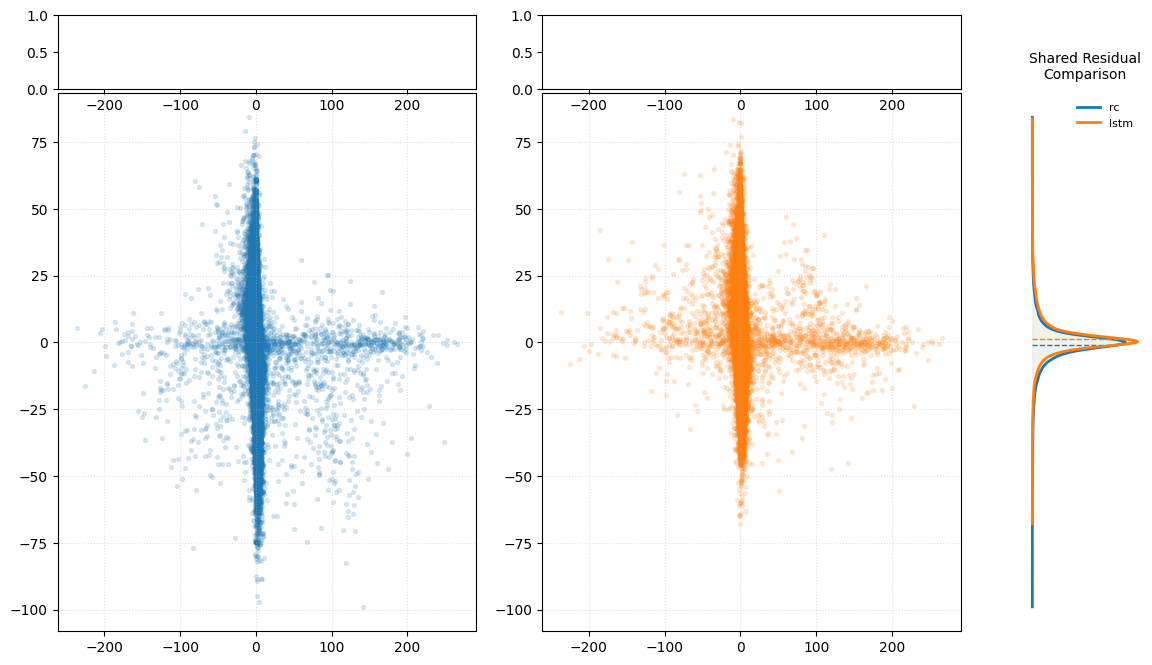

In [97]:
evaluation_framework.plot_acceleration_vs_residuals(y_true_lstm, d)

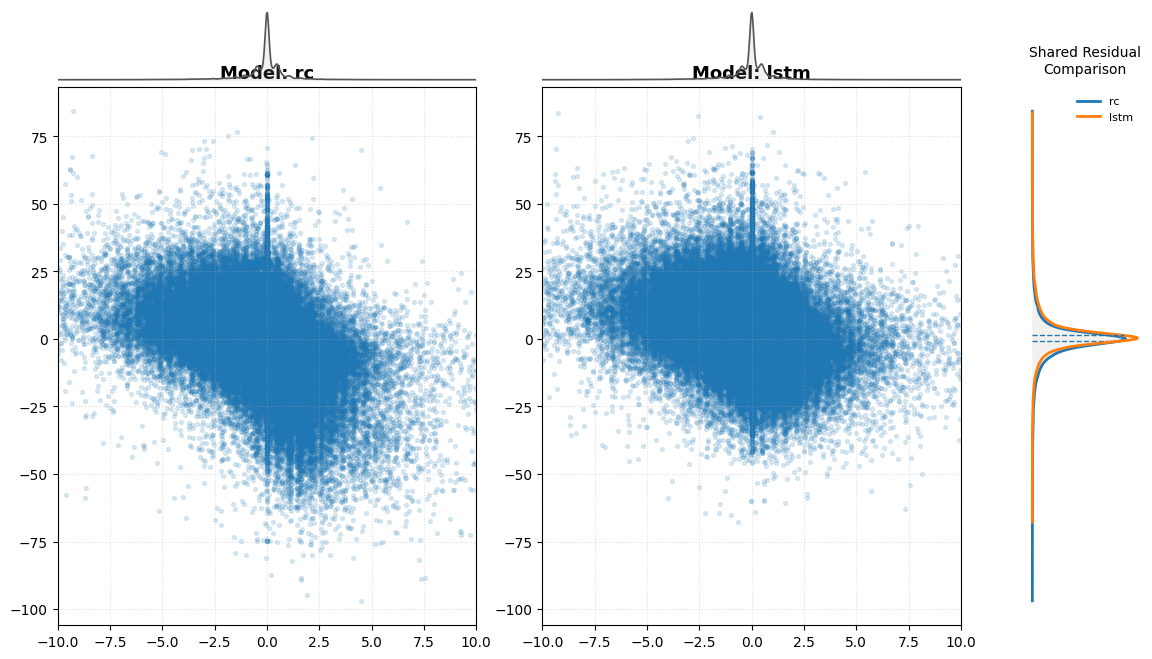

In [91]:
evaluation_framework.plot_acceleration_vs_residuals(y_true_lstm, d, acc_range=(-10, 10))


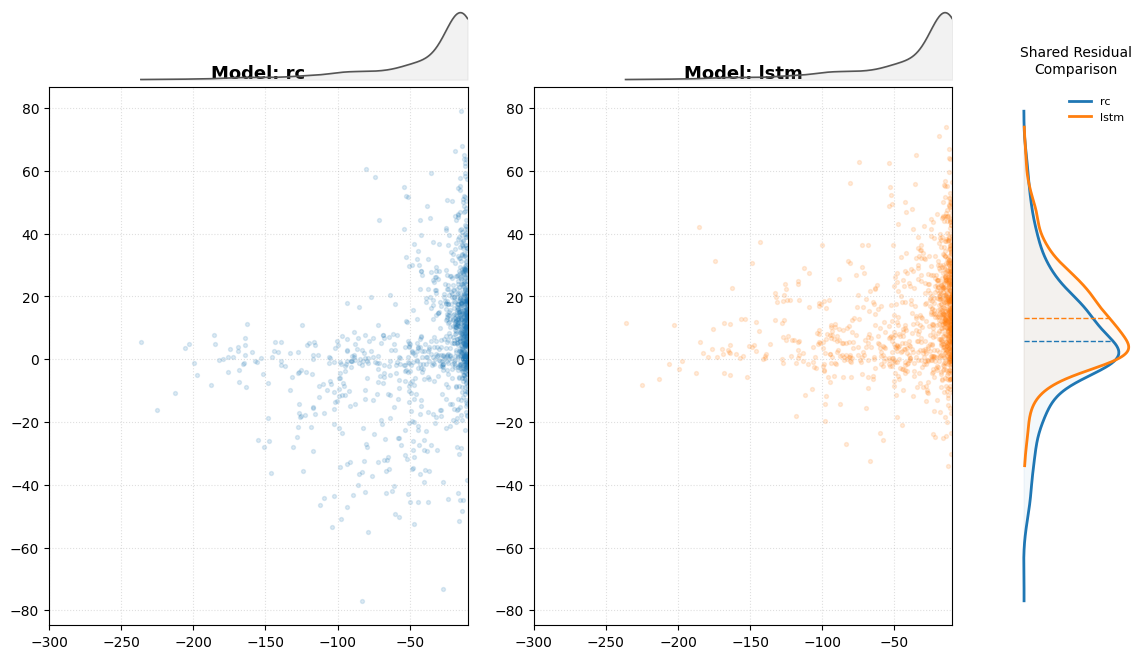

In [61]:
evaluation_framework.plot_acceleration_vs_residuals(y_true_lstm, d, acc_range=(-300, -10))


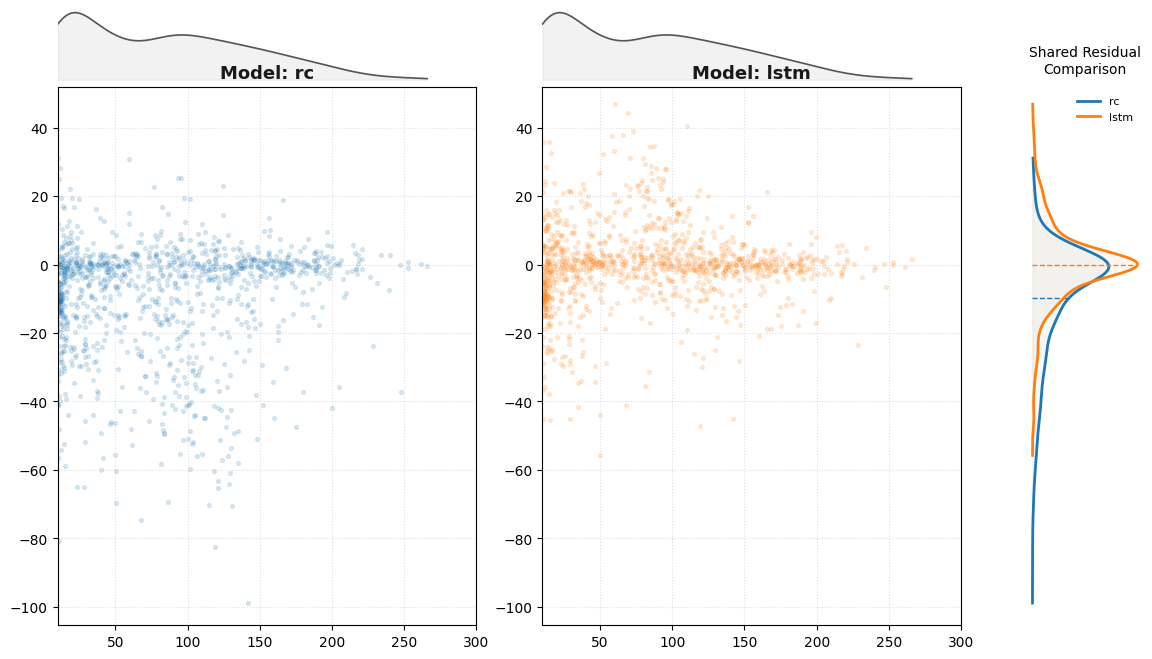

In [60]:
evaluation_framework.plot_acceleration_vs_residuals(y_true_lstm, d, acc_range=(10, 300))

C:\Users\camar\AppData\Local\Temp\ipykernel_23516\3704978420.py:169: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(all_residuals, labels=model_names, patch_artist=True,


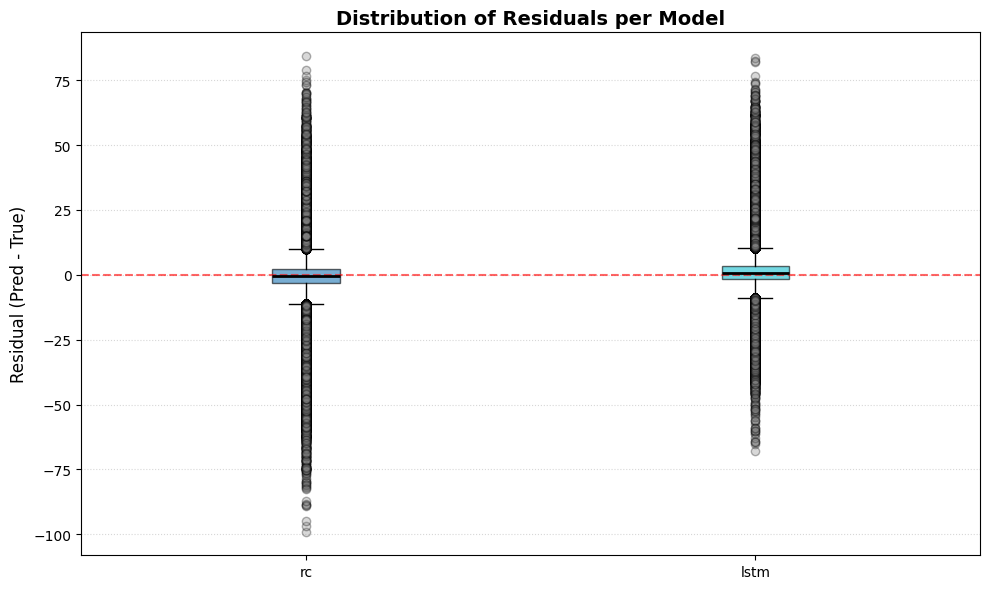

In [66]:
evaluation_framework.plot_residual_boxplot(y_true_lstm, d)

Successfully saved Plot to S3: marc.camarillas.tfm/experiments/icao_results/Flight Analysis: ac2666.1 .png


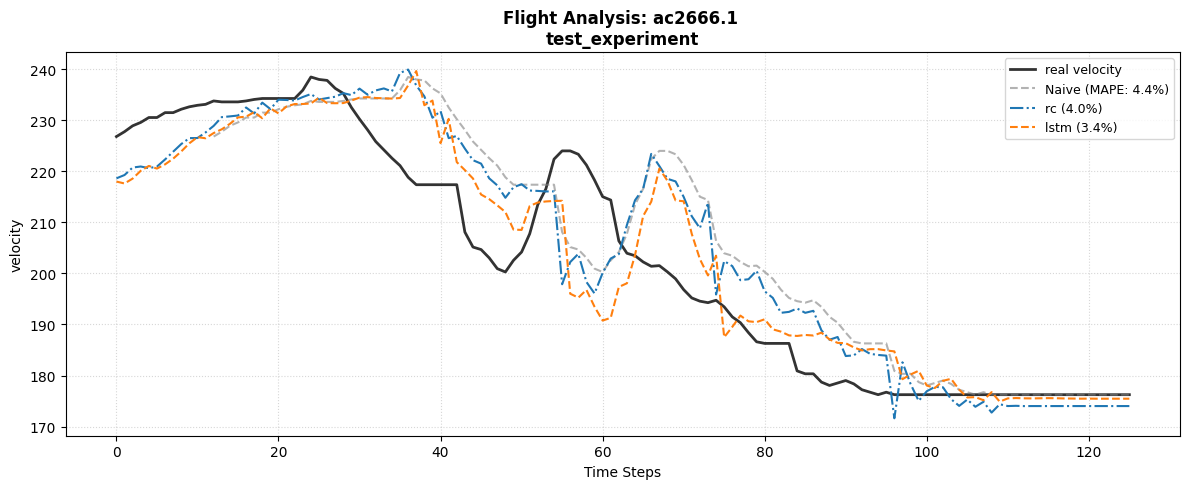

In [11]:
true_map = evaluation_framework.map_predictions_to_icao(
    y_true_lstm, 
    icao_list_test_lstm, 
    ModelType.LSTM
)

rc_results_mapped = evaluation_framework.map_predictions_to_icao(
    y_pred_rc, 
    icao_list_test_rc, 
    ModelType.RESERVOIR_COMPUTING
)

lstm_results_mapped = evaluation_framework.map_predictions_to_icao(
    y_pred_lstm, 
    icao_list_test_lstm, 
    ModelType.LSTM
)

models_to_compare = {
    "rc": rc_results_mapped,
    "lstm": lstm_results_mapped
}

evaluation_framework.plot_icao_results(icao_list_test_rc[0], true_map, models_to_compare)

In [75]:

mape_list, mse_list, r2_list = get_detailed_rankings("lstm", models_to_compare, true_map)

print("--- BEST MODELS BY MAPE ---")
print(mape_list[["icao24", "MAPE (%)"]].head(5))

print("\n--- ICAOs SORTED BY MSE (Lowest Error First) ---")
print(mse_list[["icao24", "MSE"]].head(5))

print("\n--- ICAOs SORTED BY R2 (Best Fit First) ---")
print(r2_list[["icao24", "R2"]].head(5))

--- BEST MODELS BY MAPE ---
     icao24  MAPE (%)
0  c058b4.1    0.2319
1  ad01ab.0    0.2763
2  c03f85.1    0.2840
3  acab11.1    0.2844
4  adb723.3    0.3001

--- ICAOs SORTED BY MSE (Lowest Error First) ---
     icao24     MSE
0  adf5e2.1  0.4588
1  c058b4.1  0.5837
2  acab11.1  0.6251
3  ad01ab.0  0.6384
4  adb723.3  0.6705

--- ICAOs SORTED BY R2 (Best Fit First) ---
     icao24      R2
0  ad8bed.0  0.9957
1  ad9712.1  0.9944
2  ad5460.1  0.9938
3  ad56e0.1  0.9937
4  addadb.1  0.9928



--- Statistics for ICAO: ad8bed.0 ---
Naive -> MSE: 190.4899, MAPE: 6.22%, R2: 0.97
rc -> MSE: 38.3635, MAPE: 3.08%, R2: 0.99
lstm -> MSE: 24.1881, MAPE: 2.22%, R2: 1.00


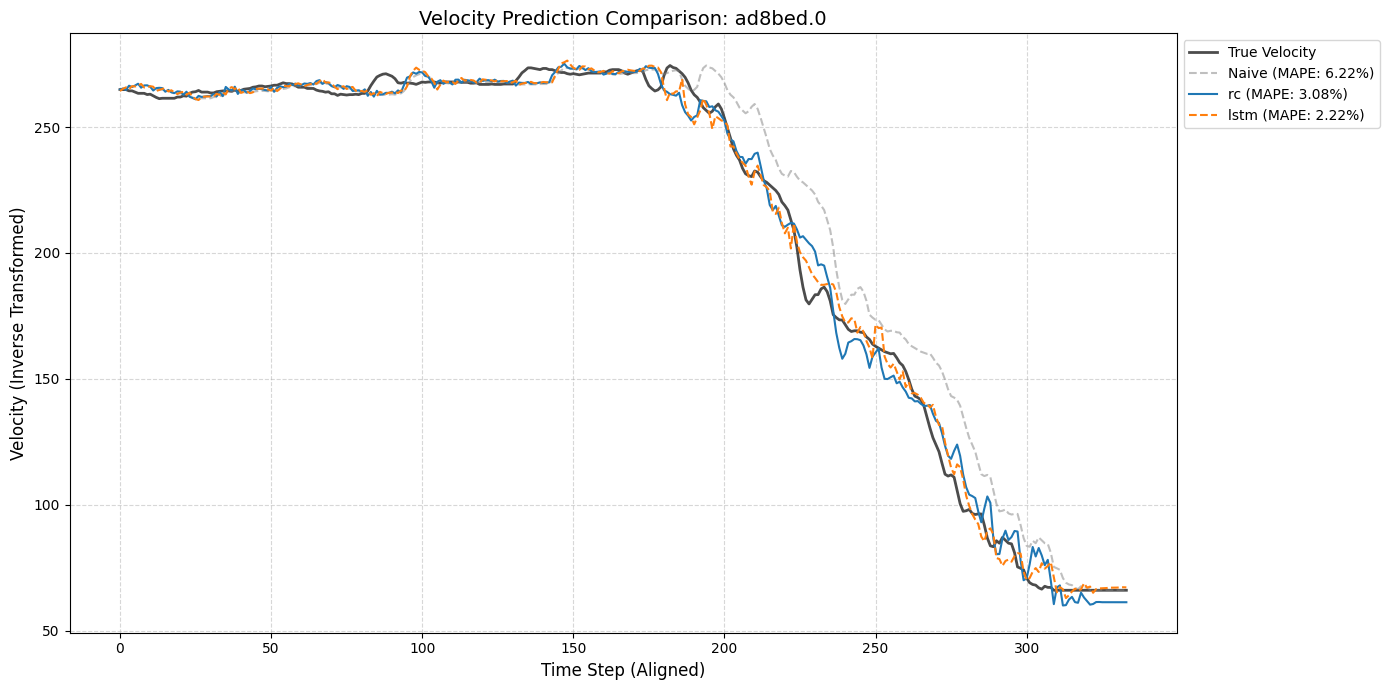

In [ ]:
evaluation_framework.plot_icao_results("ad8bed.0", true_map, models_to_compare)


--- Statistics for ICAO: ad5460.1 ---
Naive -> MSE: 152.5292, MAPE: 7.60%, R2: 0.97
rc -> MSE: 33.3735, MAPE: 4.19%, R2: 0.99
lstm -> MSE: 31.7904, MAPE: 3.72%, R2: 0.99


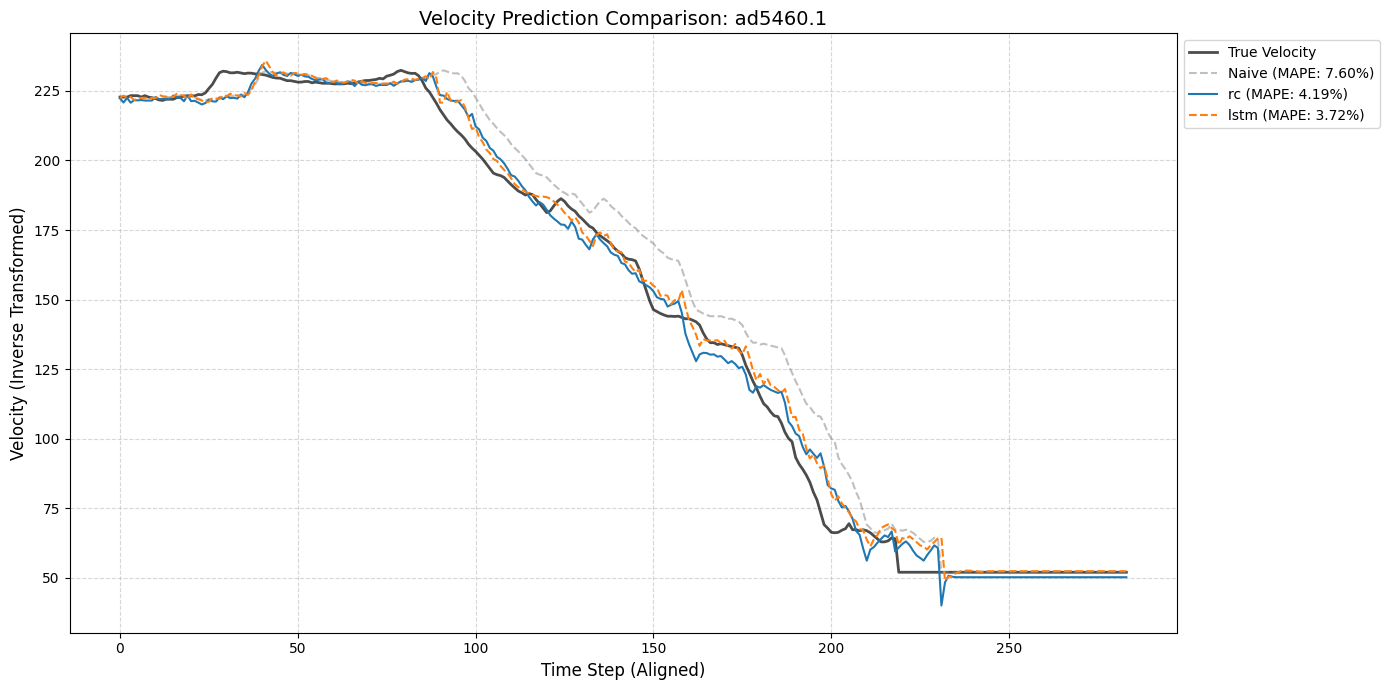

In [ ]:
evaluation_framework.plot_icao_results("ad5460.1", true_map, models_to_compare)


--- Statistics for ICAO: ad9712.1 ---
Naive -> MSE: 341.5550, MAPE: 10.21%, R2: 0.94
rc -> MSE: 56.1787, MAPE: 5.13%, R2: 0.99
lstm -> MSE: 36.6659, MAPE: 3.26%, R2: 0.99


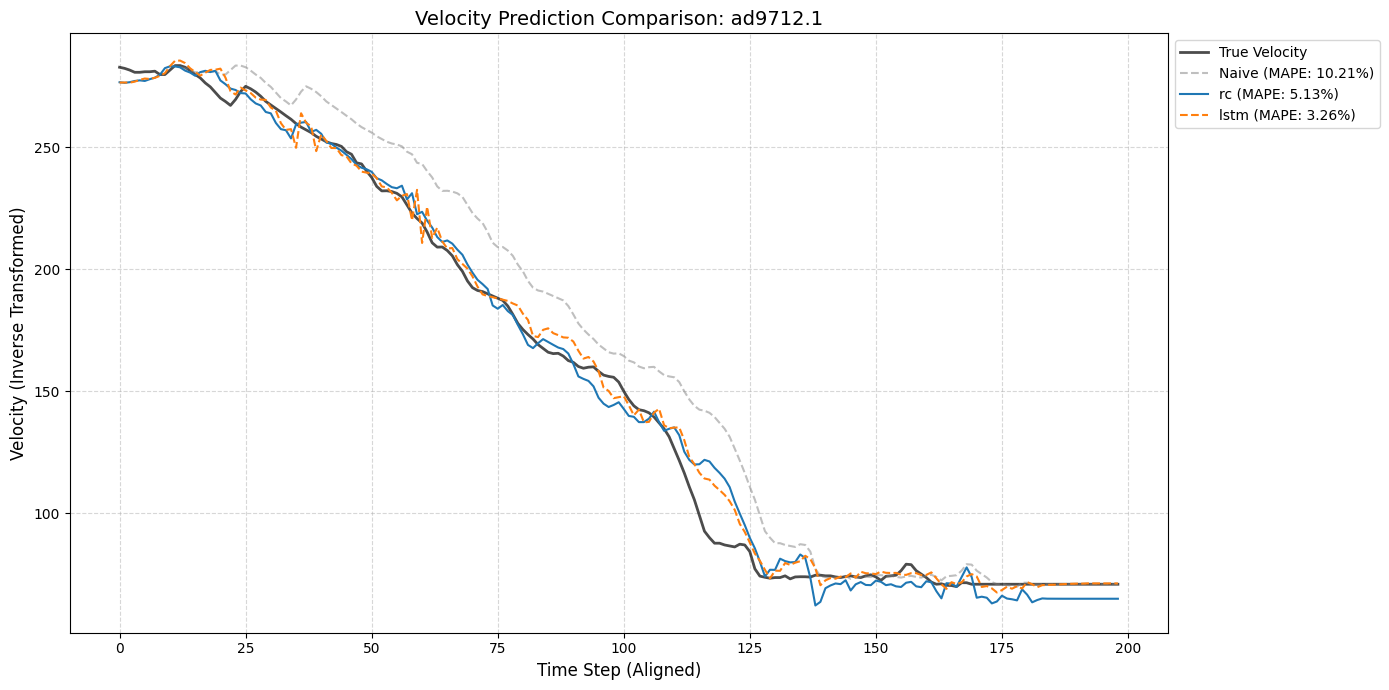

In [ ]:
evaluation_framework.plot_icao_results("ad9712.1", true_map, models_to_compare)


--- Statistics for ICAO: c058b4.1 ---
Naive -> MSE: 0.4096, MAPE: 0.18%, R2: 0.55
rc -> MSE: 3.4201, MAPE: 0.70%, R2: -2.81
lstm -> MSE: 0.5837, MAPE: 0.23%, R2: 0.35


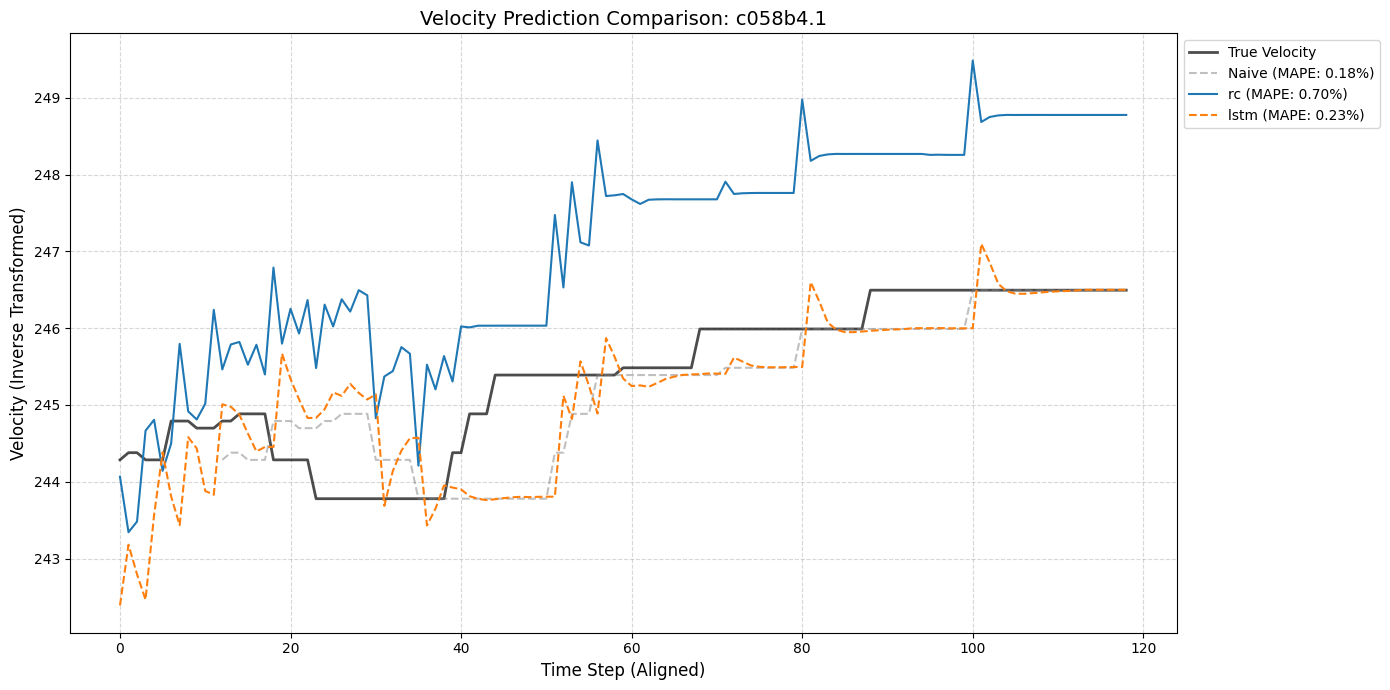

In [ ]:
evaluation_framework.plot_icao_results("c058b4.1", true_map, models_to_compare)

In [13]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
from src.utils.config import ModelType, bucket
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from src.utils.s3_io import read_json_from_s3, save_plot_to_s3
from scipy.stats import gaussian_kde

class EvaluationFramework():
    def __init__(self, transformation_file: str, target_column: str, experiment_name: str, window_size: int = 12):
        transformation_dict = read_json_from_s3(bucket, transformation_file)
        self.transformation = transformation_dict[target_column]
        self.target_column = target_column
        self.window_size = window_size
        self.experiment_name = experiment_name

    def _transform_val(self, val):
        if self.transformation["transformation"] == "std":  
            return (val * self.transformation["std"]) + self.transformation["mean"]
        return val

    def map_predictions_to_icao(self, predictions, icao_info, model_type: ModelType):
        mapped_data = {}
        if model_type == ModelType.RESERVOIR_COMPUTING:
            for icao, pred in zip(icao_info, predictions):
                flat_pred = pred.flatten()
                aligned_pred = flat_pred[self.window_size:]
                mapped_data[icao] = self._transform_val(aligned_pred)
                
        elif model_type == ModelType.LSTM:
            current_idx = 0
            for icao, count in icao_info:
                segment = predictions[current_idx : current_idx + count]
                mapped_data[icao] = self._transform_val(segment)
                current_idx += count
        return mapped_data

    def plot_icao_results(self, icao_id, true_map, model_map_dict, title_suffix=""):
        fig, ax = plt.subplots(figsize=(12, 5))
            
        y_true_flat = true_map[icao_id].flatten()
        ax.plot(y_true_flat, label=f"real {self.target_column}", color='black', linewidth=2, alpha=0.8)

        naive_pred = np.full_like(y_true_flat, np.nan)
        naive_pred[self.window_size:] = y_true_flat[:-self.window_size]
        mask = ~np.isnan(naive_pred)

        if np.any(mask):
            naive_mape = mean_absolute_percentage_error(y_true_flat[mask], naive_pred[mask]) * 100
            ax.plot(naive_pred, label=f"Naive (MAPE: {naive_mape:.1f}%)", color='gray', linestyle='--', alpha=0.6)

        line_styles = ['-.', '--', '-', ':']
        for i, (model_name, results_dict) in enumerate(model_map_dict.items()):
            if icao_id not in results_dict:
                continue
                
            preds = results_dict[icao_id].flatten()
            min_len = min(len(y_true_flat), len(preds))
            model_mape = mean_absolute_percentage_error(y_true_flat[:min_len], preds[:min_len]) * 100
            
            style = line_styles[i % len(line_styles)]
            ax.plot(preds, label=f"{model_name} ({model_mape:.1f}%)", linestyle=style, lw=1.5)

        title = f"Flight Analysis: {icao_id} {title_suffix}"
        ax.set_title(f"{title}\n{self.experiment_name}", fontsize=12, fontweight='bold')
        ax.set_ylabel(f"{self.target_column}")
        ax.set_xlabel("Time Steps")
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.legend(fontsize=9, loc='upper right', frameon=True)
        plt.tight_layout()
        
        save_plot_to_s3(fig, bucket, os.path.join("experiments", self.experiment_name, "icao_results", title))
        plt.show()

    def plot_acceleration_vs_residuals(self, y_true, predictions_dict, acc_range=None, title_label="Full Range"):
        number_models = len(predictions_dict)
        fig = plt.figure(figsize=(6 * number_models + 2, 6))
        gs = fig.add_gridspec(6, (8 * number_models) + 2, hspace=0.1, wspace=0.2)

        y_true_flat = self._transform_val(np.asanyarray(y_true).flatten())
        acceleration_full = np.diff(y_true_flat)

        if acc_range is not None:
            mask = (acceleration_full >= acc_range[0]) & (acceleration_full <= acc_range[1])
            acc_viz = acceleration_full[mask]
        else:
            mask = np.ones_like(acceleration_full, dtype=bool)
            acc_viz = acceleration_full

        ax_dist_y = fig.add_subplot(gs[1:6, -2:]) 
        main_axes = []

        for i, (model_name, y_pred) in enumerate(predictions_dict.items()):
            col_start = i * 8
            ax_main = fig.add_subplot(gs[1:6, col_start : col_start+7])
            main_axes.append(ax_main)

            y_pred_flat = self._transform_val(np.asanyarray(y_pred).flatten())
            residuals = (y_pred_flat[1:] - y_true_flat[1:])[mask]
            color = plt.cm.tab10(i % 10)

            ax_main.scatter(acc_viz, residuals, alpha=0.15, s=8, color=color)
            ax_main.axhline(0, color='black', lw=1, ls='--')
            ax_main.set_title(f"{model_name}", fontsize=11)
            ax_main.set_xlabel("Acceleration")
            if i == 0: ax_main.set_ylabel("Residual (Pred - True)")

            if len(residuals) > 1 and np.var(residuals) > 1e-9:
                kde_y = gaussian_kde(residuals)
                y_space = np.linspace(residuals.min(), residuals.max(), 200)
                ax_dist_y.plot(kde_y(y_space), y_space, color=color, lw=2, label=model_name)
                ax_dist_y.fill_betweenx(y_space, 0, kde_y(y_space), color=color, alpha=0.05)

        all_y_min = min(ax.get_ylim()[0] for ax in main_axes)
        all_y_max = max(ax.get_ylim()[1] for ax in main_axes)
        for ax in main_axes: ax.set_ylim(all_y_min, all_y_max)
        ax_dist_y.set_ylim(all_y_min, all_y_max)
        ax_dist_y.axis('off')

        title = f"Residual Analysis: {title_label}"
        fig.suptitle(f"{title}\n{self.experiment_name}", fontsize=14, fontweight='bold', y=1.02)
        save_plot_to_s3(fig, bucket, os.path.join("experiments", self.experiment_name, "acc_vs_residuals", title))
        plt.show()

    def get_detailed_rankings(self, model_name, model_map_dict, true_map):
        predictions_dict = model_map_dict.get(model_name)
        if not predictions_dict: return None, None, None

        stats = []
        for icao, y_pred in predictions_dict.items():
            if icao in true_map:
                y_true, y_p = true_map[icao].flatten(), y_pred.flatten()
                min_len = min(len(y_true), len(y_p))
                mape = mean_absolute_percentage_error(y_true[:min_len], y_p[:min_len]) * 100
                mse = mean_squared_error(y_true[:min_len], y_p[:min_len])
                r2 = r2_score(y_true[:min_len], y_p[:min_len])
                stats.append({"icao24": icao, "MAPE (%)": mape, "MSE": mse, "R2": r2})

        df = pd.DataFrame(stats)
        return (df.sort_values("MAPE (%)"), df.sort_values("MSE"), df.sort_values("R2", ascending=False))

    def run_full_report(self, model_map_dict, model_pred_dict, true_map, y_true_all):
        for model_name in list(model_map_dict.keys())[:2]:
            best_mape, _, best_r2 = self.get_detailed_rankings(model_name, model_map_dict, true_map)
            
            self.plot_icao_results(best_r2.iloc[0]['icao24'], true_map, model_map_dict, 
                                   title_suffix=f"(Best R2 for {model_name})")
            
            self.plot_icao_results(best_mape.iloc[0]['icao24'], true_map, model_map_dict, 
                                   title_suffix=f"(Best MAPE for {model_name})")

        random_icaos = np.random.choice(list(true_map.keys()), 4, replace=False)
        for icao in random_icaos:
            self.plot_icao_results(icao, true_map, model_map_dict, title_suffix="(Random Sample)")

        configs = [
            (None, "Full Range"), 
            ((-10, 10), "Stable Velocity ([-10, 10])"), 
            ((-300, -10), "Deceleration ([-300, -10])"), 
            ((10, 300), "Acceleration ([10, 300])")
        ]
        
        for rng, label in configs:
            self.plot_acceleration_vs_residuals(y_true_all, model_pred_dict, 
                                                acc_range=rng, title_label=label)

Successfully loaded JSON from S3: marc.camarillas.tfm/datasets/opensky/metadata/transformations/dataset_large_transformations.json
Successfully saved Plot to S3: marc.camarillas.tfm/experiments/test_experiment/icao_results/Flight Analysis: c080ac.0 (Best R2 for rc).png


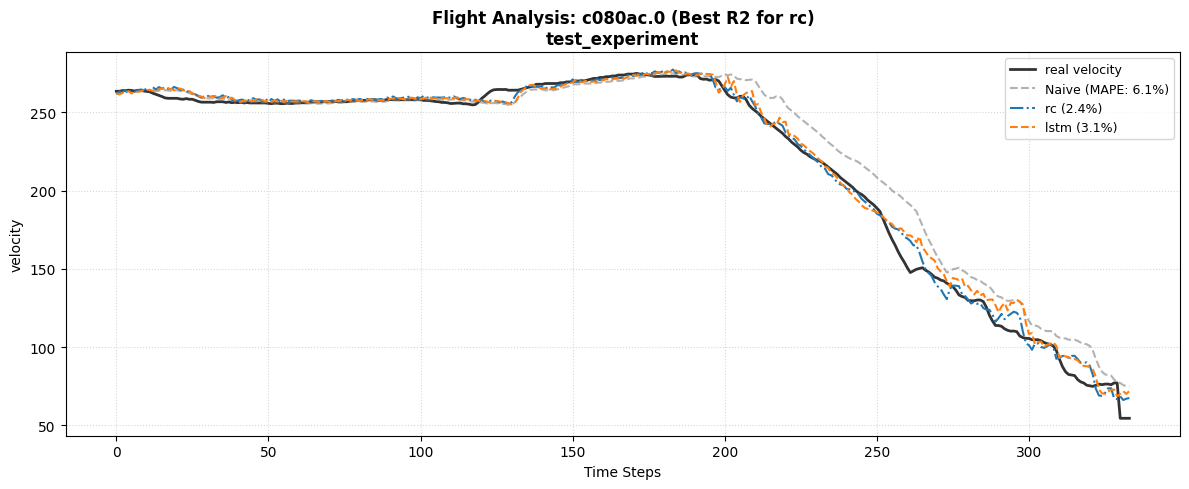

Successfully saved Plot to S3: marc.camarillas.tfm/experiments/test_experiment/icao_results/Flight Analysis: c023c8.1 (Best MAPE for rc).png


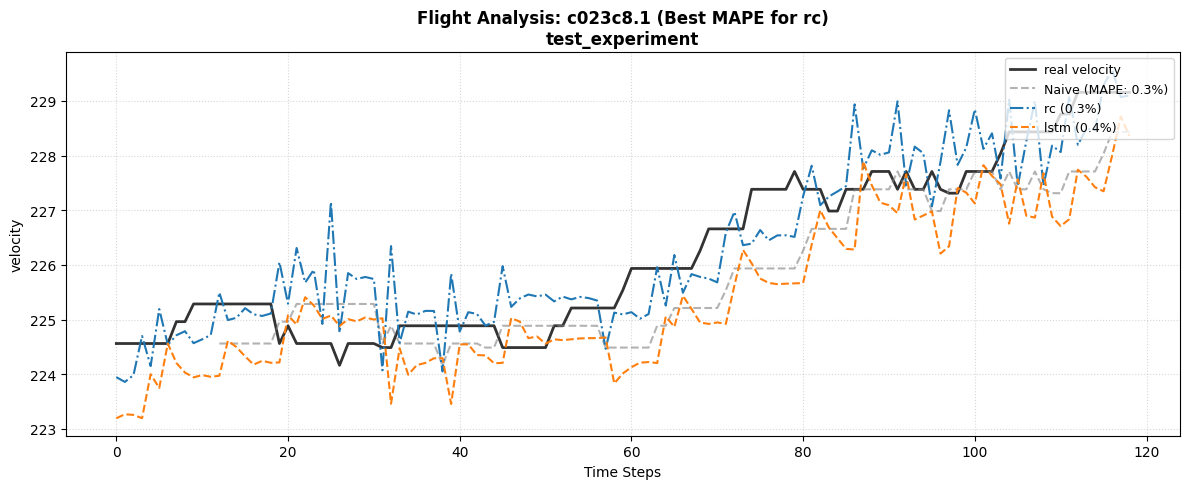

Successfully saved Plot to S3: marc.camarillas.tfm/experiments/test_experiment/icao_results/Flight Analysis: ad8bed.0 (Best R2 for lstm).png


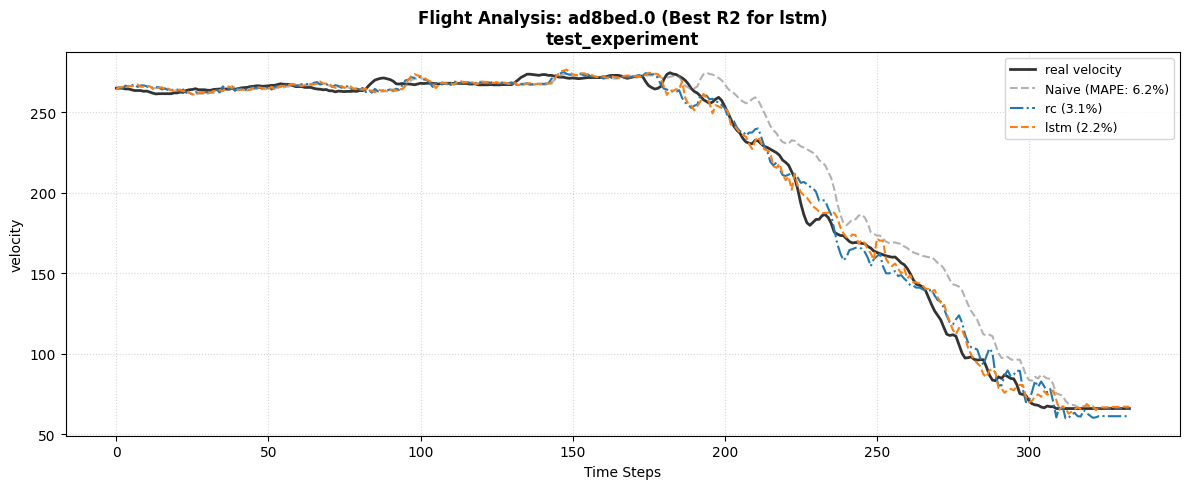

Successfully saved Plot to S3: marc.camarillas.tfm/experiments/test_experiment/icao_results/Flight Analysis: c058b4.1 (Best MAPE for lstm).png


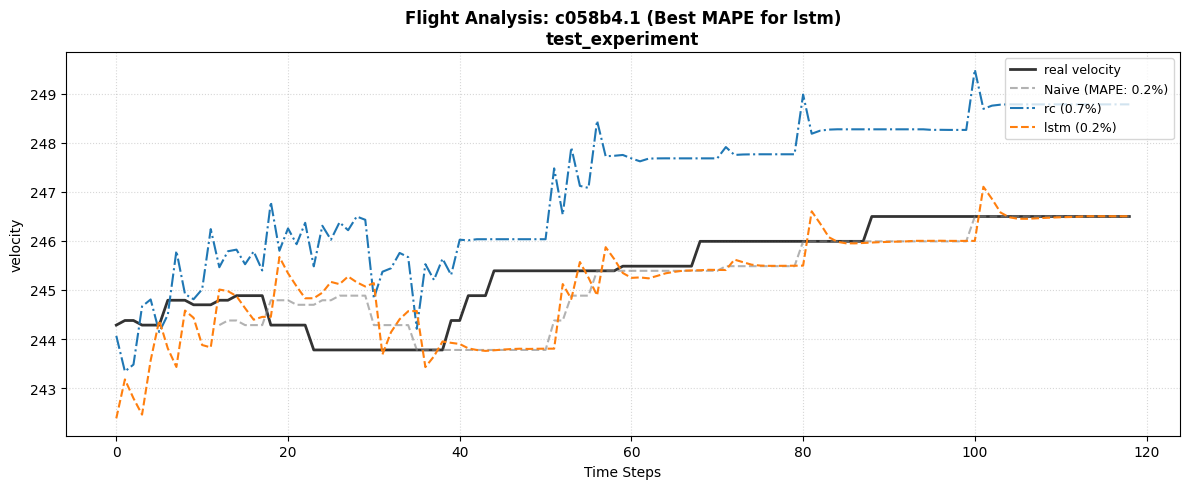

Successfully saved Plot to S3: marc.camarillas.tfm/experiments/test_experiment/icao_results/Flight Analysis: ac3c25.1 (Random Sample).png


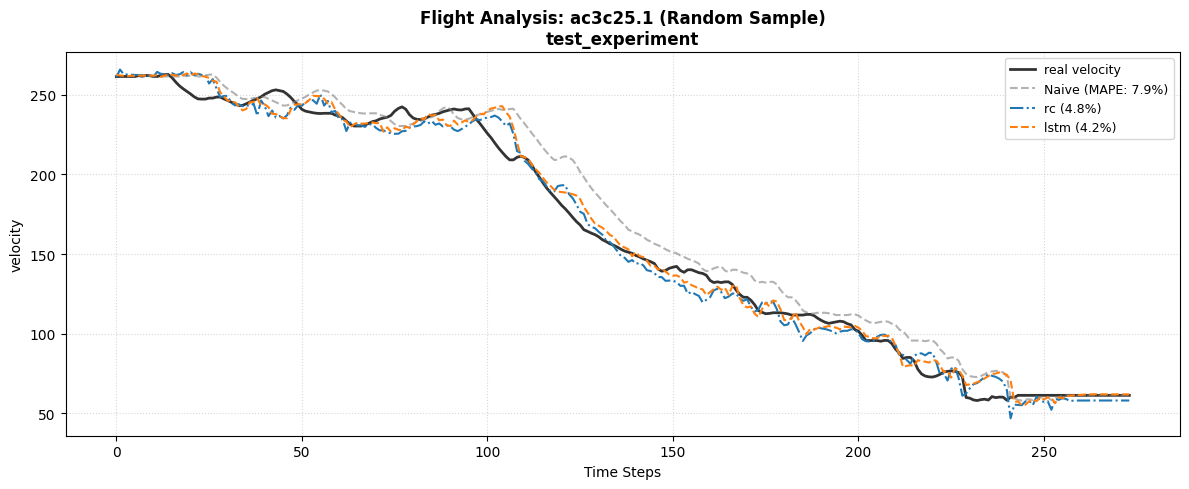

Successfully saved Plot to S3: marc.camarillas.tfm/experiments/test_experiment/icao_results/Flight Analysis: ac7a52.0 (Random Sample).png


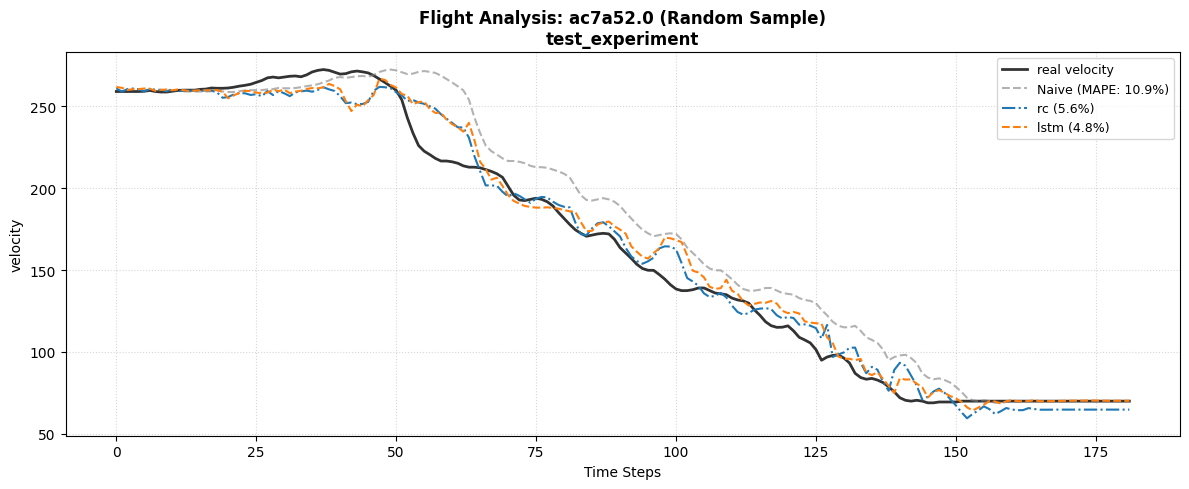

Successfully saved Plot to S3: marc.camarillas.tfm/experiments/test_experiment/icao_results/Flight Analysis: e495fb.1 (Random Sample).png


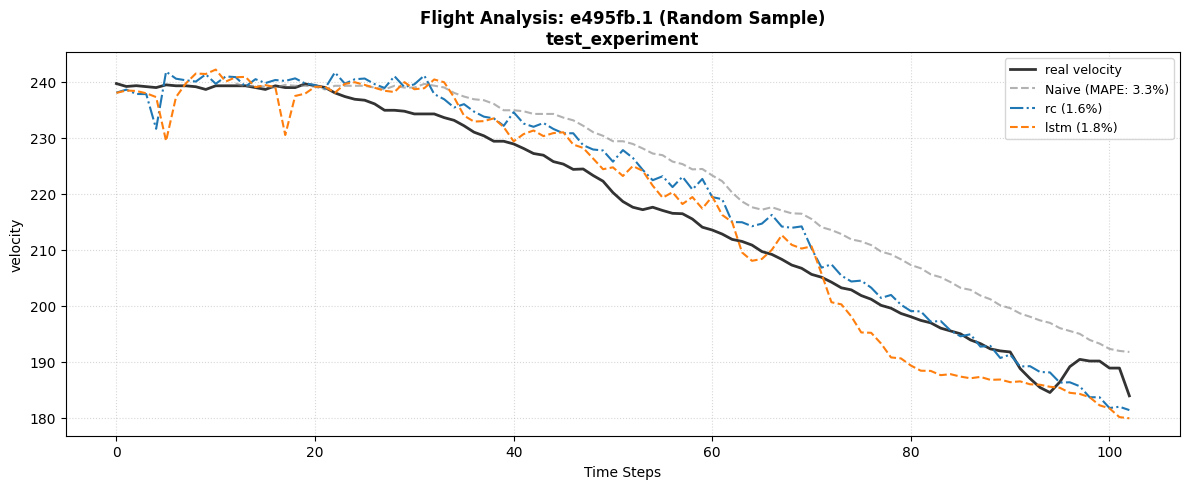

Successfully saved Plot to S3: marc.camarillas.tfm/experiments/test_experiment/icao_results/Flight Analysis: c82810.0 (Random Sample).png


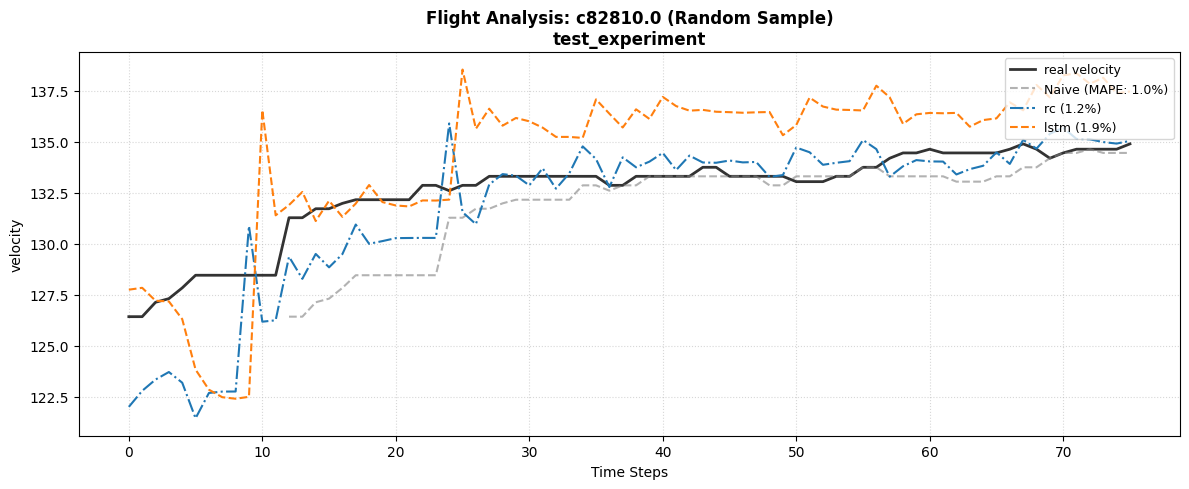

Successfully saved Plot to S3: marc.camarillas.tfm/experiments/test_experiment/acc_vs_residuals/Residual Analysis: Full Range.png


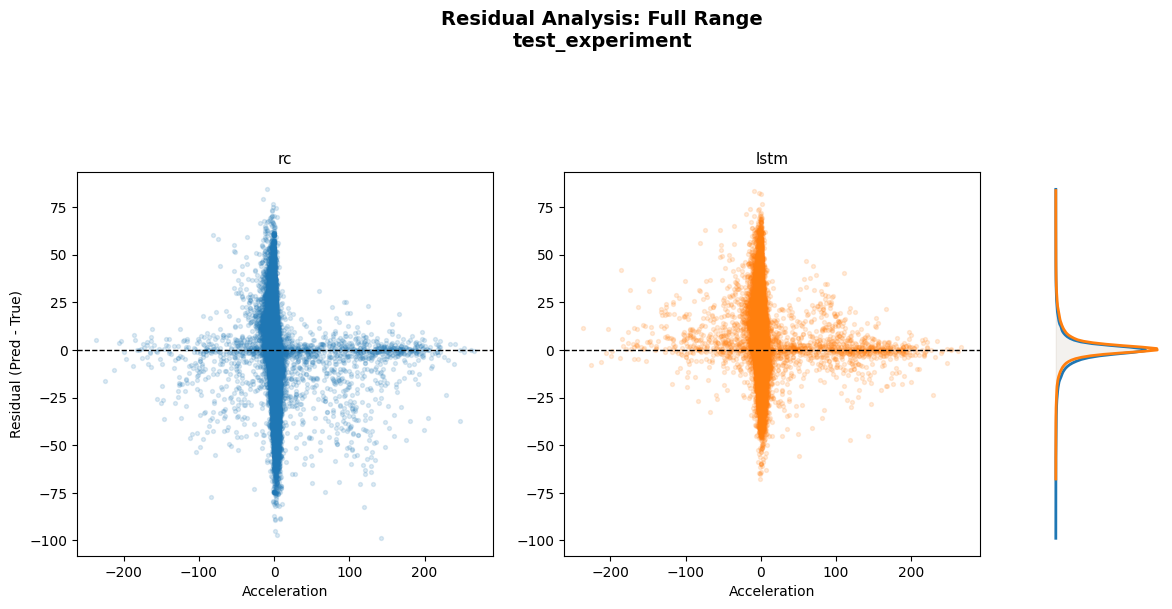

Successfully saved Plot to S3: marc.camarillas.tfm/experiments/test_experiment/acc_vs_residuals/Residual Analysis: Stable Velocity ([-10, 10]).png


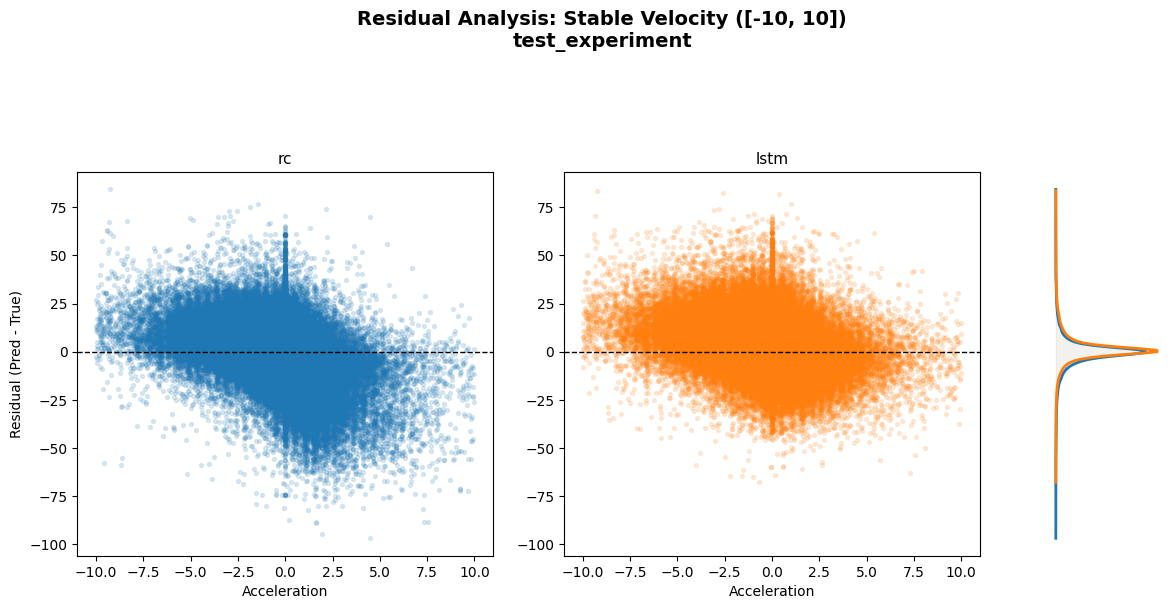

Successfully saved Plot to S3: marc.camarillas.tfm/experiments/test_experiment/acc_vs_residuals/Residual Analysis: Deceleration ([-300, -10]).png


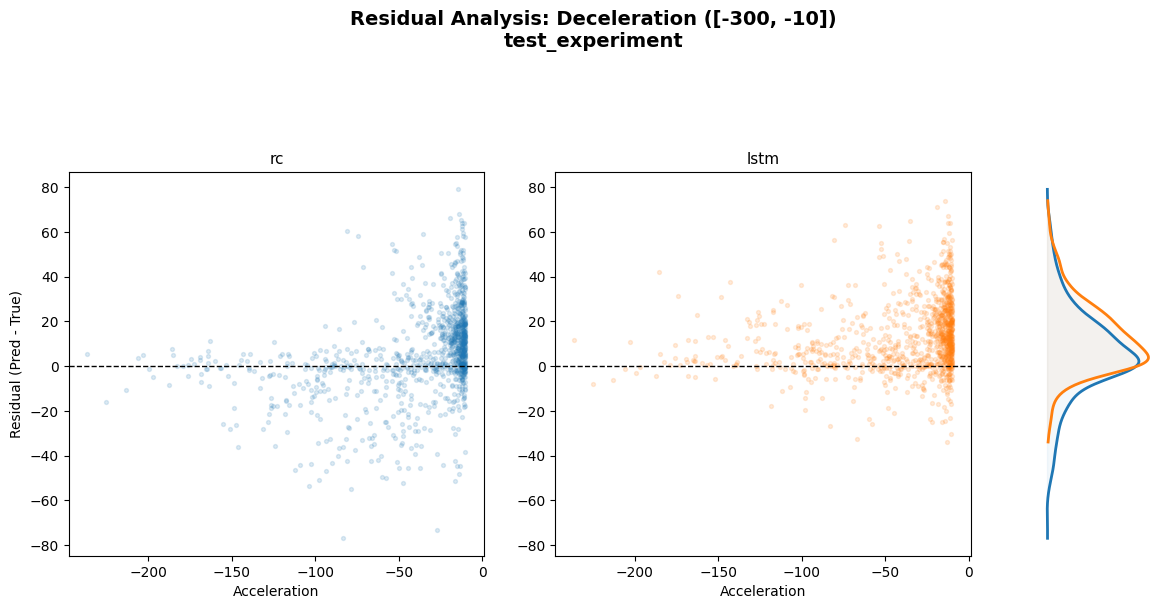

Successfully saved Plot to S3: marc.camarillas.tfm/experiments/test_experiment/acc_vs_residuals/Residual Analysis: Acceleration ([10, 300]).png


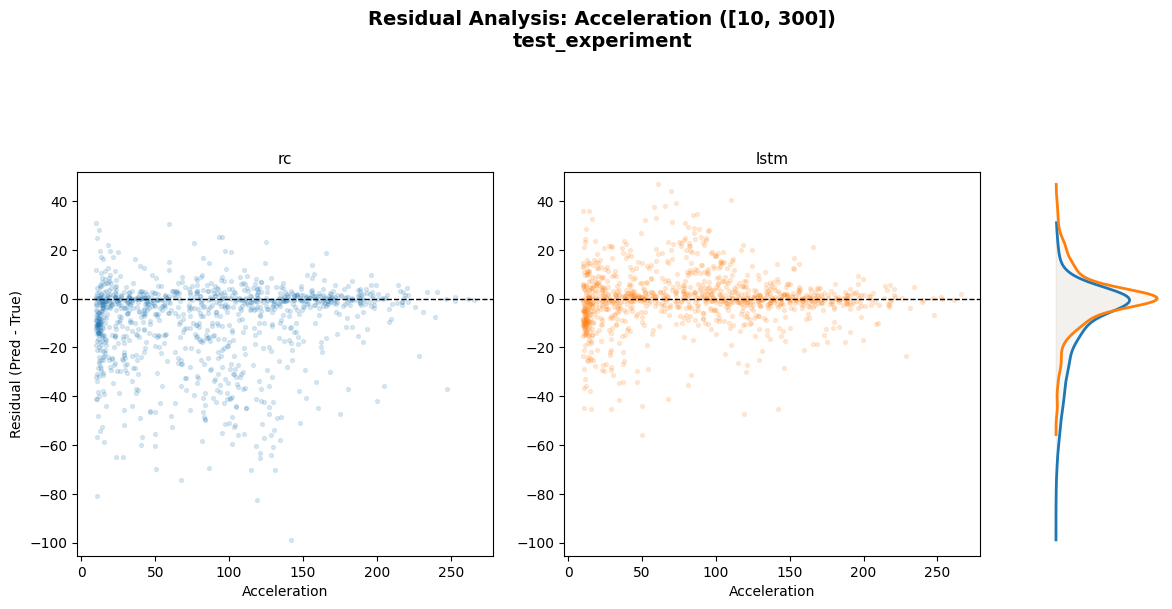

In [14]:
evaluation_framework = EvaluationFramework(
    transformation_file=f"datasets/opensky/metadata/transformations/dataset_{DATA_SUFFIX}_transformations.json", 
    target_column="velocity",
    window_size=12,
    experiment_name="test_experiment"
)

evaluation_framework.run_full_report(models_to_compare, d, true_map, y_true_lstm)